# HANDS-ON SESSION 9
## Python + Google Colab + BigQuery — Final Analysis TheLook Ecommerce

**Dataset:** `bigquery-public-data.thelook_ecommerce`  
**Level:** Basic / Pemula  
**Lanjutan:** Sesi 8 — Python Analysis

### Fokus Sesi 9
Menyelesaikan analisis Python yang akan menjadi **output akhir fase Python** dan siap diteruskan ke fase Power BI.

### Alur
**BigQuery → Pandas → KPI → Analysis → Visualization → Insight → Final Dataset**

> Tetap basic: tidak menggunakan machine learning dan tidak menggunakan JOIN kompleks.


## 1. Setup Google Colab & BigQuery

In [ ]:
!pip -q install google-cloud-bigquery db-dtypes


In [ ]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

PROJECT_ID = "my-project-2602-505412"
client = bigquery.Client(project=PROJECT_ID)

print("Connected to:", PROJECT_ID)


Connected to: my-project-2602-505412


## 2. Cek Tabel TheLook Ecommerce

In [ ]:
query = '''
SELECT
  table_name
FROM `bigquery-public-data.thelook_ecommerce.INFORMATION_SCHEMA.TABLES`
ORDER BY table_name
'''

client.query(query).to_dataframe()


,table_name
0,distribution_centers
1,events
2,inventory_items
3,order_items
4,orders
5,products
6,users


# BAGIAN A — DATA ORDERS

## 3. Ambil Data Orders dari BigQuery

In [ ]:
query = '''
SELECT
  order_id,
  user_id,
  status,
  created_at
FROM `bigquery-public-data.thelook_ecommerce.orders`
'''

orders = client.query(query).to_dataframe()

print("Rows:", orders.shape[0])
print("Columns:", orders.shape[1])


Rows: 124999
Columns: 4


## 4. Persiapan Tanggal

In [ ]:
import pandas as pd

orders["created_at"] = pd.to_datetime(
    orders["created_at"],
    errors="coerce"
)

orders["order_date"] = orders["created_at"].dt.date
orders["month"] = orders["created_at"].dt.to_period("M").astype(str)

orders.head()


/tmp/ipykernel_895/782877545.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  orders["month"] = orders["created_at"].dt.to_period("M").astype(str)


,order_id,user_id,status,created_at,order_date,month
0,10,12,Cancelled,2023-12-15 19:42:50+00:00,2023-12-15,2023-12
1,12,14,Cancelled,2025-12-04 05:03:13+00:00,2025-12-04,2025-12
2,25,22,Cancelled,2022-09-01 20:37:07+00:00,2022-09-01,2022-09
3,51,47,Cancelled,2026-07-29 12:01:00+00:00,2026-07-29,2026-07
4,58,57,Cancelled,2025-08-11 08:10:20+00:00,2025-08-11,2025-08


# BAGIAN B — FINAL KPI

## 5. Total Orders

In [ ]:
total_orders = len(orders)

print("Total Orders:", total_orders)


Total Orders: 124999


## 6. Complete Orders

In [ ]:
complete_orders = (
    orders["status"] == "Complete"
).sum()

print("Complete Orders:", complete_orders)


Complete Orders: 31576


## 7. Complete Rate

In [ ]:
complete_rate = round(
    complete_orders / total_orders * 100,
    2
)

print("Complete Rate:", complete_rate, "%")


Complete Rate: 25.26 %


## 8. Status Summary

In [ ]:
status_summary = (
    orders["status"]
    .value_counts()
    .reset_index()
)

status_summary.columns = [
    "status",
    "total_orders"
]

status_summary["percentage"] = (
    status_summary["total_orders"]
    / total_orders * 100
).round(2)

status_summary


,status,total_orders,percentage
0,Shipped,37246,29.80
1,Complete,31576,25.26
2,Processing,25026,20.02
3,Cancelled,18736,14.99
4,Returned,12415,9.93


# BAGIAN C — TIME ANALYSIS

## 9. Monthly Orders

In [ ]:
monthly_orders = (
    orders.groupby("month")
    .size()
    .reset_index(name="total_orders")
)

monthly_orders


,month,total_orders
0,2019-01,5
1,2019-02,20
2,2019-03,36
3,2019-04,40
4,2019-05,61
...,...,...
87,2026-04,3814
88,2026-05,4475
89,2026-06,4797
90,2026-07,5603


## 10. Top 5 Bulan

In [ ]:
top_months = (
    monthly_orders
    .sort_values("total_orders", ascending=False)
    .head(5)
)

top_months


,month,total_orders
91,2026-08,10263
90,2026-07,5603
89,2026-06,4797
88,2026-05,4475
87,2026-04,3814


## 11. Complete Orders per Month

In [ ]:
complete_monthly = (
    orders[orders["status"] == "Complete"]
    .groupby("month")
    .size()
    .reset_index(name="complete_orders")
)

complete_monthly


,month,complete_orders
0,2019-03,11
1,2019-04,11
2,2019-05,13
3,2019-06,15
4,2019-07,22
...,...,...
85,2026-04,983
86,2026-05,1104
87,2026-06,1262
88,2026-07,1410


## 12. Gabungkan Monthly Analysis

In [ ]:
monthly_analysis = monthly_orders.merge(
    complete_monthly,
    on="month",
    how="left"
).fillna(0)

monthly_analysis["complete_orders"] = (
    monthly_analysis["complete_orders"].astype(int)
)

monthly_analysis["complete_rate"] = (
    monthly_analysis["complete_orders"]
    / monthly_analysis["total_orders"]
    * 100
).round(2)

monthly_analysis


,month,total_orders,complete_orders,complete_rate
0,2019-01,5,0,0.00
1,2019-02,20,0,0.00
2,2019-03,36,11,30.56
3,2019-04,40,11,27.50
4,2019-05,61,13,21.31
...,...,...,...,...
87,2026-04,3814,983,25.77
88,2026-05,4475,1104,24.67
89,2026-06,4797,1262,26.31
90,2026-07,5603,1410,25.17


## 13. Visualisasi Monthly Orders

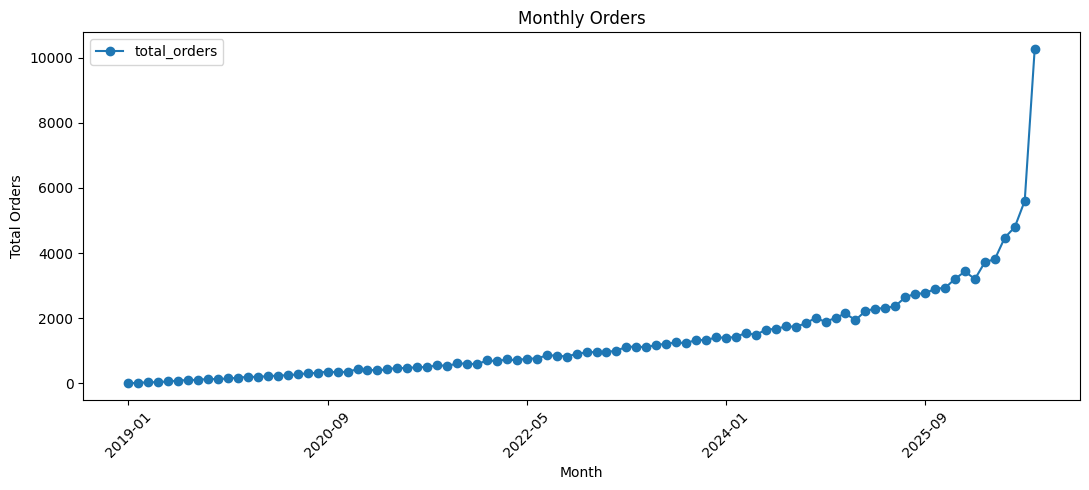

In [ ]:
import matplotlib.pyplot as plt

monthly_analysis.plot(
    x="month",
    y="total_orders",
    kind="line",
    marker="o",
    figsize=(11,5)
)

plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 14. Visualisasi Complete Rate

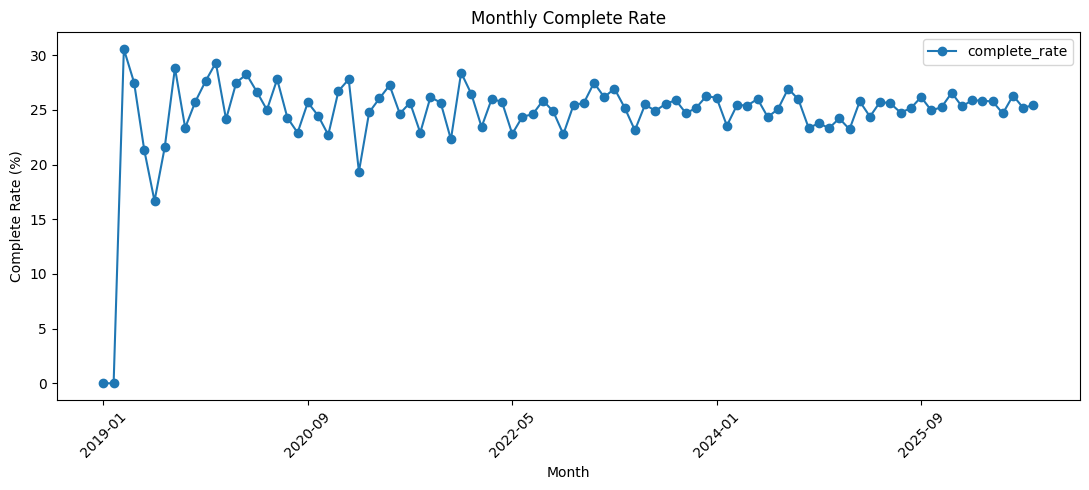

In [ ]:
monthly_analysis.plot(
    x="month",
    y="complete_rate",
    kind="line",
    marker="o",
    figsize=(11,5)
)

plt.title("Monthly Complete Rate")
plt.xlabel("Month")
plt.ylabel("Complete Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# BAGIAN D — DAILY ANALYSIS

## 15. Orders per Date

In [ ]:
daily_orders = (
    orders.groupby("order_date")
    .size()
    .reset_index(name="total_orders")
    .sort_values("total_orders", ascending=False)
)

daily_orders.head(10)


,order_date,total_orders
2728,2026-08-29,1757
2727,2026-08-28,1099
2726,2026-08-27,775
2725,2026-08-26,566
2724,2026-08-25,420
2723,2026-08-24,334
2721,2026-08-22,264
2711,2026-08-12,260
2720,2026-08-21,253
2714,2026-08-15,253


## 16. Top 10 Hari

In [ ]:
top_days = daily_orders.head(10)

top_days


,order_date,total_orders
2728,2026-08-29,1757
2727,2026-08-28,1099
2726,2026-08-27,775
2725,2026-08-26,566
2724,2026-08-25,420
2723,2026-08-24,334
2721,2026-08-22,264
2711,2026-08-12,260
2720,2026-08-21,253
2714,2026-08-15,253


# BAGIAN E — USER ANALYSIS

## 17. Ambil Users dari BigQuery

In [ ]:
query_users = '''
SELECT
  id AS user_id,
  first_name,
  last_name,
  gender,
  age,
  country
FROM `bigquery-public-data.thelook_ecommerce.users`
'''

users = client.query(query_users).to_dataframe()

print("Rows:", users.shape[0])
users.head()


Rows: 100000


,user_id,first_name,last_name,gender,age,country
0,75132,Linda,Howard,F,12,Brasil
1,63916,Derrick,Jones,M,12,Japan
2,55805,Julie,Ford,F,12,United States
3,60740,Joseph,Roberts,M,12,United States
4,55270,Donald,Daniels,M,12,United States


## 18. User Summary

In [ ]:
average_age = round(users["age"].mean(), 2)

gender_summary = (
    users["gender"]
    .value_counts()
    .reset_index()
)

gender_summary.columns = [
    "gender",
    "total_users"
]

country_summary = (
    users["country"]
    .value_counts()
    .reset_index()
)

country_summary.columns = [
    "country",
    "total_users"
]

print("Average Age:", average_age)
display(gender_summary)


Average Age: 41.02


,gender,total_users
0,F,50045
1,M,49955


## 19. Top 10 Country

In [ ]:
top_country = country_summary.head(10)

top_country


,country,total_users
0,China,33928
1,United States,22535
2,Brasil,14699
3,South Korea,5372
4,France,4818
5,United Kingdom,4476
6,Germany,4195
7,Spain,3895
8,Japan,2461
9,Australia,2138


## 20. Visualisasi Top Country

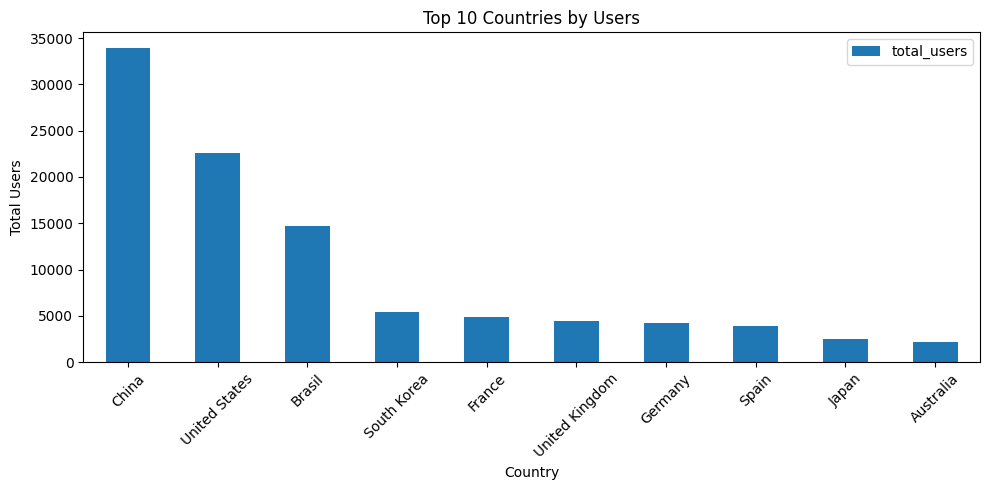

In [ ]:
top_country.plot(
    x="country",
    y="total_users",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries by Users")
plt.xlabel("Country")
plt.ylabel("Total Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# BAGIAN F — FINAL BUSINESS SUMMARY

## 21. Buat KPI Table

In [ ]:
kpi = pd.DataFrame({
    "metric": [
        "Total Orders",
        "Complete Orders",
        "Complete Rate",
        "Average User Age"
    ],
    "value": [
        total_orders,
        complete_orders,
        complete_rate,
        average_age
    ]
})

kpi


,metric,value
0,Total Orders,124999.00
1,Complete Orders,31576.00
2,Complete Rate,25.26
3,Average User Age,41.02


## 22. Business Questions

Gunakan output di atas untuk menjawab:

1. Berapa total order?
2. Berapa Complete Rate?
3. Status apa yang paling dominan?
4. Bulan mana dengan order tertinggi?
5. Bagaimana trend Complete Rate?
6. Country mana yang memiliki user terbanyak?
7. Apa 3 insight utama dari data?


In [ ]:
print("===== FINAL SUMMARY =====")
print("Total Orders    :", total_orders)
print("Complete Orders :", complete_orders)
print("Complete Rate   :", complete_rate, "%")
print("Average Age     :", average_age)

print("\nTop Status:")
display(status_summary.head(1))

print("\nTop Month:")
display(top_months.head(1))

print("\nTop Country:")
display(top_country.head(1))


===== FINAL SUMMARY =====
Total Orders    : 124999
Complete Orders : 31576
Complete Rate   : 25.26 %
Average Age     : 41.02

Top Status:


,status,total_orders,percentage
0,Shipped,37246,29.8



Top Month:


,month,total_orders
91,2026-08,10263



Top Country:


,country,total_users
0,China,33928


# BAGIAN G — TULIS INSIGHT

## 23. Insight 1 — Overall

In [ ]:
insight_1 = ""

print("Insight 1:", insight_1)


## 24. Insight 2 — Trend

In [ ]:
insight_2 = ""

print("Insight 2:", insight_2)


## 25. Insight 3 — User / Country

In [ ]:
insight_3 = ""

print("Insight 3:", insight_3)


### Panduan Menulis Insight

Gunakan pola:

**Angka / pola → apa yang terlihat → maknanya secara deskriptif**

Hindari klaim sebab-akibat jika tidak dibuktikan oleh data.


# BAGIAN H — EXPORT FINAL DATA

## 26. Export Dataset Orders

In [ ]:
orders.to_csv(
    "thelook_orders_final_session9.csv",
    index=False
)

print("Dataset orders berhasil diexport.")


## 27. Export Summary untuk Power BI

File-file ini dapat digunakan sebagai referensi ketika membuat dashboard Power BI.


In [ ]:
kpi.to_csv("session9_kpi.csv", index=False)
status_summary.to_csv("session9_status_summary.csv", index=False)
monthly_analysis.to_csv("session9_monthly_analysis.csv", index=False)
top_country.to_csv("session9_top_country.csv", index=False)

print("Semua summary berhasil dibuat.")


In [ ]:
from google.colab import files

files.download("thelook_orders_final_session9.csv")


# BAGIAN I — FINAL QUALITY CHECK

## 28. Cek Sebelum Masuk Power BI

In [ ]:
print("===== FINAL QUALITY CHECK =====")
print("Rows             :", len(orders))
print("Columns          :", len(orders.columns))
print("Missing Values   :", int(orders.isna().sum().sum()))
print("Duplicate Rows   :", int(orders.duplicated().sum()))
print("Invalid Dates    :", int(orders["created_at"].isna().sum()))
print("Total Orders     :", total_orders)
print("Complete Orders  :", complete_orders)
print("Complete Rate    :", complete_rate, "%")


===== FINAL QUALITY CHECK =====
Rows             : 124999
Columns          : 6
Missing Values   : 0
Duplicate Rows   : 0
Invalid Dates    : 0
Total Orders     : 124999
Complete Orders  : 31576
Complete Rate    : 25.26 %


# MINI PROJECT SESI 9

### Project: TheLook Ecommerce Analysis

Peserta harus memiliki:

- 4 KPI utama.
- Status analysis.
- Monthly Orders.
- Monthly Complete Rate.
- Daily Orders.
- Top Country.
- Minimal 3 insight.
- Dataset final.
- Summary CSV.

### Handoff ke Power BI

**Python Final Analysis**
→ **Final Dataset**
→ **Google Sheets / Excel**
→ **Power BI Dashboard**

Project tetap menggunakan dataset TheLook Ecommerce yang sama.


# LATIHAN MANDIRI

### Soal 1
Buat visualisasi jumlah order berdasarkan status.

### Soal 2
Buat analisis 5 bulan dengan Complete Rate tertinggi.

### Soal 3
Buat satu KPI tambahan.

### Soal 4
Cari country dengan jumlah user paling sedikit di antara country yang memiliki minimal 1.000 user.

### Soal 5
Tuliskan 3 insight berbeda dari hasil analisis.

**Tools:** Pandas + Matplotlib + BigQuery.


In [6]:
!pip -q install google-cloud-bigquery db-dtypes

from google.colab import auth
auth.authenticate_user()
import pandas as pd
import matplotlib.pyplot as plt

from google.cloud import bigquery

PROJECT_ID = "my-project-2602-505412"
client = bigquery.Client(project=PROJECT_ID)

print("Connected to:", PROJECT_ID)



Connected to: my-project-2602-505412


In [7]:
#JAWABAN SOAL 1

query = """
SELECT
    status,
    COUNT(order_id) AS jumlah_order
FROM `bigquery-public-data.thelook_ecommerce.orders`
GROUP BY status
ORDER BY jumlah_order DESC
"""

df_status = client.query(query).to_dataframe()

df_status


,status,jumlah_order
0,Shipped,37587
1,Complete,31447
2,Processing,24916
3,Cancelled,18630
4,Returned,12523


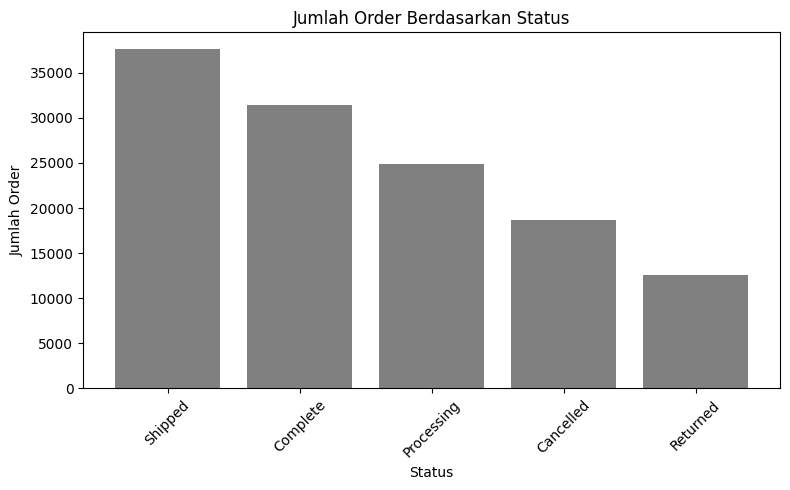

In [10]:
plt.figure(figsize=(8, 5))

plt.bar(
    df_status["status"],
    df_status["jumlah_order"],
    color = "grey")

plt.title("Jumlah Order Berdasarkan Status")
plt.xlabel("Status")
plt.ylabel("Jumlah Order")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [11]:
#JAWABAN NOMOR 2

query = """
SELECT
    FORMAT_DATE('%Y-%m', DATE(created_at)) AS bulan,

    COUNT(order_id) AS total_order,

    COUNTIF(status = 'Complete') AS complete_order,

    SAFE_DIVIDE(
        COUNTIF(status = 'Complete'),
        COUNT(order_id)
    ) * 100 AS complete_rate

FROM `bigquery-public-data.thelook_ecommerce.orders`

GROUP BY bulan
ORDER BY complete_rate DESC
"""

df_complete = client.query(query).to_dataframe()

df_complete.head(5)


,bulan,total_order,complete_order,complete_rate
0,2019-07,104,32,30.769231
1,2021-02,373,112,30.026810
2,2020-01,197,58,29.441624
3,2019-03,48,14,29.166667
4,2019-06,78,22,28.205128


In [12]:
#JAWABAN NOMOR 3

query = """
SELECT
    SUM(sale_price) AS total_sales,
    COUNT(DISTINCT order_id) AS total_order,
    SAFE_DIVIDE(
        SUM(sale_price),
        COUNT(DISTINCT order_id)
    ) AS average_order_value
FROM `bigquery-public-data.thelook_ecommerce.order_items`
"""

df_kpi = client.query(query).to_dataframe()

df_kpi

aov = df_kpi.loc[0, "average_order_value"]

print(f"Average Order Value: ${aov:,.2f}")


Average Order Value: $86.44


In [13]:
#JAWABAN NOMOR 4

query = """
SELECT
    country,
    COUNT(id) AS jumlah_user
FROM `bigquery-public-data.thelook_ecommerce.users`
GROUP BY country
HAVING COUNT(id) >= 1000
ORDER BY jumlah_user ASC
LIMIT 1
"""

df_country = client.query(query).to_dataframe()

df_country


,country,jumlah_user
0,Belgium,1242


In [14]:
#JAWABAN NOMOR 5

insight_1 = "Belgium adalah negara dengan jumlah user paling sedikit dengan data hanya 1242 user"

print("Insight 1:", insight_1)


insight_2 = "AOV atau Average Order Value adalah KPI Tambahan dengan  nilai $86.44"

print("Insight 2:", insight_2)


insight_3 = "Complete Rate tertinggi pada bulan Juli 2017 di angka 30,77%"

print("Insight 3:", insight_3)

Insight 1: Belgium adalah negara dengan jumlah user paling sedikit dengan data hanya 1242 user
Insight 2: AOV atau Average Order Value adalah KPI Tambahan dengan  nilai $86.44
Insight 3: Complete Rate tertinggi pada bulan Juli 2017 di angka 30,77%
